# Notebook 6 — Did the event increase firing?

**Summer course: data-analysis pitfalls**

For each neuron we measured firing in a baseline window and in a response window
after an event. To combine neurons with very different baseline rates, a
colleague normalized each neuron to its own baseline (a fold-change) and averaged:

> ### The claim
> *"The event increased firing: the mean response is about 130% of baseline (a
> ~30% increase) across the population."*

Run it and you'll get ~1.3x.

**The claim is false.** Your job is to work out *why*. `hints.md` has guiding
questions and `notebook6_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

# We intentionally divide by (occasionally zero) baselines below and handle the
# resulting non-finite values with np.isfinite; silence the expected warning.
np.seterr(divide='ignore', invalid='ignore')


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
d = np.load('data/data.npz')
pre_counts = d['pre_counts']       # (neurons, trials) spike counts, baseline window
post_counts = d['post_counts']     # (neurons, trials) spike counts, response window
duration = float(d['duration'])    # s per window
n_neurons, n_trials = pre_counts.shape
pre_rate  = pre_counts.mean(1) / duration      # per-neuron mean baseline rate (spikes/s)
post_rate = post_counts.mean(1) / duration     # per-neuron mean response rate
print(f'{n_neurons} neurons, {n_trials} trials per window')


200 neurons, 5 trials per window


## Normalize each neuron to its baseline and average


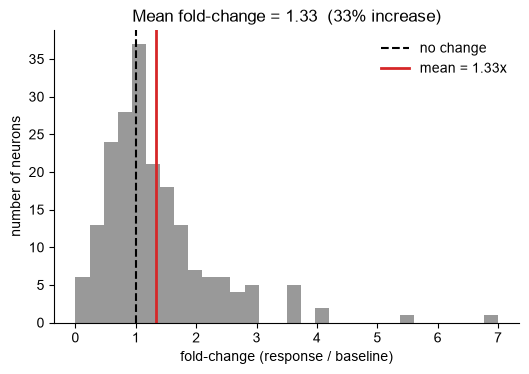

In [3]:
fold = post_rate / pre_rate                 # per-neuron fold-change (response / baseline)
fold = fold[np.isfinite(fold)]              # drop neurons with zero baseline (can't divide)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.hist(fold, bins=30, color='0.6')
ax.axvline(1.0, color='k', ls='--', label='no change')
ax.axvline(fold.mean(), color='tab:red', lw=2, label=f'mean = {fold.mean():.2f}x')
ax.set_xlabel('fold-change (response / baseline)'); ax.set_ylabel('number of neurons')
ax.set_title(f'Mean fold-change = {fold.mean():.2f}  ({(fold.mean()-1)*100:.0f}% increase)')
ax.legend(frameon=False)
plt.show()


A ~30% increase, on average. The event drives the population up.
